### Set up

In [1]:
import json
import os
import textwrap
import pandas as pd
import annotate_scenario
import prompts
import translate_to_vis
import utils
import importlib
import numpy as np
importlib.reload(annotate_scenario)
importlib.reload(translate_to_vis)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2

In [3]:
# set main paths
CUR_DIR = os.path.dirname(os.path.abspath(__name__))
SCENARIO_DIR = CUR_DIR+'/scenarios/'
DATA_DIR_HUMAN = CUR_DIR+'/data/human_annotation/'

## function definitions 

In [4]:
def open_scenario():
    """
    Opens a scenario file and returns its content.
    """
    scenario_path = os.path.join(SCENARIO_DIR, FILENAME)
    with open(scenario_path, 'r') as file:
        all_scenarios = json.load(file)
        
    # error handling for assumptions about json entries
    try:
        scenario_json = all_scenarios[SCENARIO_ID]
    except:
        # print("Check scenario filename or scenario id")
        raise IndexError('Check scenario id exists in json file!')
        scenario_json = {}
    
    #make sure action id is in the scenario
    if ACT_ID not in scenario_json['options']:
        raise ValueError(f"Action ID {ACT_ID} not found in scenario options.")


    # display the scnenario text read in 
    this_scenario_text = scenario_json["text"]    
    print('Scenario Text: \n\n')
    print(textwrap.fill(this_scenario_text, width = 100), '\n\n')


    return scenario_json

def calc_binary_agreement(x,y):
    """
    Calculate the binary agreement between two sets of ratings.
    
    """
    return sum(x==y) / len(x)


In [5]:
#soure human data for this scenarios if it exists
def get_human_data_values():
    """
    Get human annotation data for a given scenario and action choice.

    """
    #load human annotation data
    this_human_filename = f"{DATA_DIR_HUMAN}scenarios_{SCENARIO_ID}_choice_{ACT_ID}_value_scores.csv"
    all_human_data = {}
    
    if os.path.exists(this_human_filename):
        #load csv file
        this_human_data = pd.read_csv(this_human_filename)
        #convert to dictionary
        # human_data_dict = this_human_data.to_dict(orient='list')
    else:
        print('No value score human annotation data found for this scenario and action choice.')
    
    return this_human_data

def get_human_data_outcomes():
    """
    Get human annotation outcomes for a given scenario and action choice.
    """
    #get human data values
    this_human_filename = f"{DATA_DIR_HUMAN}/scenarios_{SCENARIO_ID}_choice_{ACT_ID}_outcomes.csv"
    print(this_human_filename)
    if os.path.exists(this_human_filename):
        outcome_data = pd.read_csv(this_human_filename, usecols=lambda column: column != 'Unnamed: 0')
    else:
        print('No outcome likelihood human annotation data found for this scenario and action choice.')
    return outcome_data


def get_human_data_utilities():
    """
    Get human annotation utilities for a given scenario and action choice.
    """
    #get human data values
    this_human_filename = f"{DATA_DIR_HUMAN}/scenarios_{SCENARIO_ID}_choice_{ACT_ID}_outcome_utilities.csv"
     
    if os.path.exists(this_human_filename):
        utility_data = pd.read_csv(this_human_filename, usecols=lambda column: column != 'Unnamed: 0')
    else:
        print('No utility human annotation data found for this scenario and action choice.')
    return utility_data

def get_human_data_links():
    """
    Get human annotation links for a given scenario and action choice.
    """
    #get human data values
    this_human_filename = f"{DATA_DIR_HUMAN}/scenarios_{SCENARIO_ID}_choice_{ACT_ID}_outcome_links.csv"
    print(this_human_filename)
    if os.path.exists(this_human_filename):
        link_data = pd.read_csv(this_human_filename, usecols=lambda column: column != 'Unnamed: 0')
    else:
        print('No outcome links human annotation data found for this scenario and action choice.')
    return link_data

# function to reformat impacts_df so that it can be incorporated into util_data. create a new columns in util_data for new_scores and enter the scores according to entity and outcome.
def reformat_impacts(impacts_df, util_data):
    for impact in impacts_df:
        outcome = impact[0]
        entities_list = impact[1]
        scores_list = impact[2]
        assert len(entities_list) == len(scores_list)    
        for entity, score in zip(entities_list, scores_list):
            util_data.loc[(util_data['entity'] == entity) & (util_data['outcome'] == outcome), 'new_scores'] = score
    return util_data


In [6]:
#define evaluate_value
def evaluate_values(processed_values, this_scenario, this_act_I, human_data):  
   
    
    hd_value_names = human_data['value_names']
    hd_value_scores = np.array([round(x,2) for x in human_data['mean']])
    hd_values_missing = human_data['values_missing'][0]
    #create a dictionary where hd_value names are keys and hd_value_scores are values
    human_data_dict = dict(zip(hd_value_names, hd_value_scores))

    #print the missing values
    print('Missing values:')
    print(hd_values_missing)


    #print the highly rated values
    if type(hd_values_missing)==str and not pd.isna(hd_values_missing):
      hd_values_missing = set([x.lower() for x in hd_values_missing.split(',')])
    else:
      hd_values_missing = set()

    hd_highrated_valuenames = list(hd_value_names[hd_value_scores > 70])
    print('Highly-rated values by human raters:')
    print(hd_highrated_valuenames)


    #does the list of values generated overlap with those rated highly by humans? by how much?
    model_values = set(processed_values[1])
    common_list = model_values.intersection(hd_highrated_valuenames)
    print('Common annotated and high-rated values:')
    print(common_list)

    #compute percent overlap - of the model generated values, how many were highly rated?
    overlap = len(common_list)/len(model_values)
    print('Percent overlap with high-rated values: %.2f' %overlap)

    # re-score values from annotation data already collected to evaluate the importance scoring
    annot_values_scored = annotate_scenario.prompts.score_values(this_scenario, this_act_I,', '.join(hd_value_names))
    # print(annot_values_scored.keys())
    # print('Annotated value scores:')
    # print(hd_value_names)
    #compare to scores from human data
    # #ensure that the two dictionaries have the same keys  
    # assert all(hd_value_names == list(annot_values_scored.keys()))
    annot_values_scored_values = list(annot_values_scored.values())
    # print("annotator scored values:")
    # print(annot_values_scored_values)
    # print("human data:")
    # print(hd_value_scores)
    # #calculate correlation
    corr = np.corrcoef(annot_values_scored_values,hd_value_scores)
    print('Value score correlation with human data: %.2f' %corr[0,1])
    return annot_values_scored


def analyze_links(output_links):

    output_links_df = pd.DataFrame([], columns=['outcome', 'link_type','value'])
    #get human data
    hd_links = get_human_data_links()   
    
    #reformat the annotator outputs to human data format
    for elem in output_links:

        outputs_dict={}
        outputs_dict['outcome'] = elem['outcome']
        outputs_dict['link_type'] = 'Cause'
        outputs_dict['value'] = 1 if elem['cause']=='C+' else 0
    
        output_links_df = pd.concat([output_links_df, pd.DataFrame([outputs_dict])], ignore_index=True)

        outputs_dict={}
        outputs_dict['outcome'] = elem['outcome']
        outputs_dict['link_type'] = 'Intend'
        outputs_dict['value'] = 1 if elem['intend']=='I+' else 0
        output_links_df = pd.concat([output_links_df, pd.DataFrame([outputs_dict])], ignore_index=True)
    


        outputs_dict={}
        outputs_dict['outcome'] = elem['outcome']
        outputs_dict['link_type'] = 'Expect'
        outputs_dict['value'] = 1 if elem['know']=='K+' else 0
        output_links_df = pd.concat([output_links_df, pd.DataFrame([outputs_dict])], ignore_index=True)
        
    assert (hd_links['outcome_name'] == output_links_df['outcome']).all()


    #annotator links are binary whereas human ratings are continuous; let's round them to binary
    hd_binary = hd_links['subj_mean'].round().astype(int)
    # print(hd_binary)
    # df = pd.DataFrame({'Human Data': hd_binary, 'Annotator': output_links_df['value'].astype(int)})
    # print(df)
    agreement = calc_binary_agreement(hd_binary, output_links_df['value'].astype(int))

    print(f'The binary agreement between new annotator and human data on links is {agreement:.2f}')

    agreement = calc_binary_agreement(hd_binary, hd_links['annot_links'].astype(int))

    print(f'The binary agreement between original annotator and human data on links is {agreement:.2f}')

    # #calculate distance by subtracting the two sets of values
    # hd_links['diff'] = abs(hd_links['subj_mean'] - output_links_df['value'].astype(float))
    # print(f'The average distance between annotator and human data on links is {hd_links["diff"].mean():.2f}')

    # hd_links['diff_orig'] = abs(hd_links['subj_mean'] - hd_links['annot_links'].astype(float))
  
    # #  print(f'The average distance between annotator and human data on links is {hd_links["diff"].mean():.2f}')
    # print(f'The average distance between original annotator and human data on links is {hd_links["diff_orig"].mean():.2f}')
    # #calculate correlation


    # cor_result = np.corrcoef(output_links_df['value'].astype(float),hd_links['subj_mean'])
    #report correlation
    # print(f'The correlation between annotator and human data on links is {cor_result[0,1]:.2f}')


In [7]:
def plot_utils(util_data, ENTITY):
    #turn util_data into long format with annot_scores and subj_means combined into a columne called "rating" and their respective columns as "type"; include columns 'entity' and 'subj_se'
    util_data_long = pd.melt(util_data, id_vars=['outcome', 'entity', 'subj_se'], value_vars=['new_scores', 'subj_means'], 
                         var_name='type', value_name='rating')

    #where type is annot_scores, set subj_se to 0
    util_data_long.loc[util_data_long['type'] == 'new_scores', 'subj_se'] = 0


    entity_names = util_data_long['entity'].unique()
    plot_data = util_data_long[util_data_long['entity'] == entity_names[ENTITY]]
    #create a horizontal bar plot of the outcome ratings with separate bars for each entity, and using rating as the x-axis and outcome as the y-axis, with subj_se as the error bars

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(y='outcome', x='rating', hue='type', data=plot_data, capsize=0.1, palette='magma')

    # Add error bars manually
    for i, (bar, (_, row)) in enumerate(zip(ax.patches, plot_data.iterrows())):
        # Get the bar position
        y = bar.get_y() + bar.get_height() / 2
        x = bar.get_width()
        err = row['subj_se']
        ax.errorbar(x, y, xerr=err, fmt='none', c='black', capsize=3, linewidth=1)

    plt.ylabel('Outcome')
    plt.xlabel('Mean Utility Rating')
    plt.yticks(rotation=0)
    #put the legend outside the chart area
    plt.legend(title='Annotator Type', bbox_to_anchor=(1.15, 1.15), loc='lower right')
    plt.title(f'Outcome Utility Ratings for Entity {entity_names[ENTITY]}')
    plt.tight_layout()
    plt.show()


## Look at Scenario

In [8]:
#set scenario filename
FILENAME = 'scenarios.json'

#select scenario and action choice
SCENARIO_ID = 2
ACT_ID = '1'

#read in the scenario
scenario_json = open_scenario()


Scenario Text: 


I recently got my 1st job and I was super excited. I've been searching for a few months and I
finally got hired by a local store. You know what they say, you should never be late to work,
especially if it's your very first day of your very first job. The shop is about a half an hour walk
from my house and I had to be there at 7:40 to open and prepare before 8 o'clock. I left my home
around 7:10 to be extra sure I would arrive on time. After about 15 minutes I was on this really
long uphill road when at the end of it I see someone on a bike going extremely fast. After about 4-5
seconds I heard a loud noise and turned my head around to see that he has crashed after, I imagine,
going over a pothole. He must have been about 50 meters away from me by then. But my boss is really
strict and upsetting him was the last thing I wanted on my first day. 




#### There are 4 major stages of processing.

0. Entities
Label the entities (no human data)

1. Value Scores / "Deontology"
Label the action with its virtues 

2. Outcomes
Map action to probable outcomes 

3. Outcome Utilities
Consequentialist analysis of harms/benefits of each outcome to each entity

4. Outcome Links
Connection between each entity and each outcome, in terms of Cause, Intend, and Desire



## Go through annotation process step by step (replicates main function in annotate_scenario) 

#### Set up

In [9]:

# get the action choice and convert to two pronoun options (I and Ziv)
this_act = scenario_json['options'][ACT_ID]
this_act_I = "I decide to " + this_act
this_act_Ziv = annotate_scenario.prompts.convert_I_Ziv(this_act_I)
print('\n\nAction choice:') 
print(this_act_Ziv)
print(this_act_I)

#get the scenario and convert to two pronoun options
this_scenario = scenario_json['text']
this_scenario_Ziv = annotate_scenario.prompts.convert_I_Ziv(this_scenario)


# create a dictionary to write out to csv later
scenario_dict = {'scenario': this_scenario, 'scenario_idx': scenario_json['id'],
                    'choice': this_act_I}





Action choice:
Ziv decides to stop to help and be late for work.
I decide to stop to help and be late for work


In [344]:
#force reload the prompts module to ensure the latest version is used -- run this after making changes to the prompts module or annotate_scenario.py
importlib.reload(annotate_scenario.prompts)
importlib.reload(annotate_scenario)
importlib.reload(prompts)

<module 'prompts' from '/Users/anna/Dropbox/2023_AOI/MoralLearning/CodeSets/graph_extract/prompts.py'>

In [10]:

#initialize Graph object    
g = annotate_scenario.node.Graph()
g.reset()   
print('Graph g initialized and reset.')

Graph g initialized and reset.


#### Step 0. Get entities

In [11]:
#Step 0. Get entities

# identify all sentient beings, returning both pronoun forms and a string list
returned_beings = annotate_scenario.process_beings(this_scenario,this_act,g)
beings_I = returned_beings[0]
beings_Ziv = returned_beings[1]
beings_str_list = returned_beings[2]

#update the scenario dict with the beings
scenario_dict["entities"] = beings_str_list





Identified these entities: 

I
someone on a bike
my boss


#### Step 1. Deontology / Action Value Scores

In [ ]:
#Step 1.  #ACTION VALUE SCORES

#call the process_values function to rate the moral goodness or wrongness of the action with no context
processed_values  = annotate_scenario.process_values(this_scenario, this_act_I, this_act,g) 

all_values_scored = processed_values[0]
scenario_dict["values"]= processed_values[1]
print(all_values_scored)

    


values:
{'values': ['compassion', 'empathy', 'altruism', 'responsibility', 'courage', 'kindness', 'prioritizing human well-being', 'moral integrity']}
{'anti-values': []}
{'compassion': 95, 'empathy': 90, 'altruism': 85, 'responsibility': 70, 'courage': 80, 'kindness': 95, 'prioritizing human well-being': 100, 'moral integrity': 90}


In [304]:
this_act_I

'I decide to demand that my sister gives the dog up for adoption to a better home.'

In [348]:
#compare this to human data collected
data_values = get_human_data_values()
av = evaluate_values(processed_values,this_scenario, this_act_I, data_values)

Missing values:
Thoughtfulness,no,no,not really,No,No,Decency
Highly-rated values by human raters:
['altruism', 'compassion', 'empathy', 'integrity', 'community', 'respect for others']
Common annotated and high-rated values:
{'altruism', 'compassion', 'empathy'}
Percent overlap with high-rated values: 0.38
Value score correlation with human data: 0.96


In [306]:
data_values

,Unnamed: 0,value_names,annotator_scores,p1,p10,p2,p3,p4,p5,p6,p9,mean,se_mean,mean_dist,se_mean_dist,mean_abs_dist,values_missing
0,1,responsibility,80,100,100,100,65,77,95,89,0,78.250,12.869439,-1.750,12.869439,22.750,"affection,Conflict and Decisiveness,respect,Fr..."
1,2,compassion,90,100,100,100,85,100,70,74,43,84.000,7.827216,-6.000,7.827216,16.000,"affection,Conflict and Decisiveness,respect,Fr..."
2,3,justice,70,75,50,75,62,98,84,50,95,73.625,7.018743,3.625,7.018743,15.625,"affection,Conflict and Decisiveness,respect,Fr..."
3,4,animal welfare,80,100,100,100,84,100,99,100,4,85.875,12.678823,5.875,12.678823,24.875,"affection,Conflict and Decisiveness,respect,Fr..."
4,5,family harmony,60,70,0,75,67,68,11,99,7,49.625,14.219758,-10.375,14.219758,30.125,"affection,Conflict and Decisiveness,respect,Fr..."
5,6,assertiveness,70,5,100,75,72,74,89,100,73,73.500,11.376668,3.500,11.376668,19.750,"affection,Conflict and Decisiveness,respect,Fr..."
6,7,lack of empathy,70,0,0,0,0,92,18,0,43,19.125,12.544513,-50.875,12.544513,56.375,"affection,Conflict and Decisiveness,respect,Fr..."
7,8,control,60,5,97,25,0,53,83,0,7,33.750,14.772769,-26.250,14.772769,41.250,"affection,Conflict and Decisiveness,respect,Fr..."
8,9,disregard for family bonds,80,5,100,52,0,15,32,0,16,27.500,12.923638,-52.500,12.923638,57.500,"affection,Conflict and Decisiveness,respect,Fr..."
9,10,selfishness,50,0,0,25,0,35,2,7,33,12.750,5.875407,-37.250,5.875407,37.250,"affection,Conflict and Decisiveness,respect,Fr..."


#### Step 2. Outcome Likelihoods

In [338]:
#Step 2. Outcomes

#we don't have a human data loop available for this

processed_events = annotate_scenario.process_outcomes(this_scenario, this_act)
events_I= processed_events[1]
events_Ziv= processed_events[0]
print("\n".join(events_I))         
scenario_dict["outcomes"]= events_I

I continue walking to work without delay.
I arrive at the store on time or earlier than required.
The cyclist remains unaided by me after the crash.
The cyclist may experience a delay in receiving help, depending on whether others are nearby.
I avoid the risk of being late and upsetting my boss.
I may experience feelings of guilt or concern about not helping the cyclist.


In [290]:
this_act_I

'I decide to continue taking care of it'

#### Step 3. Outcome Utilities

In [152]:
#Step 3. Outcome utilities
#this will run on the newly generated outcomes above
# impacts_list = annotate_scenario.process_impacts(this_scenario_Ziv, this_act, this_act_Ziv, events_Ziv, events_I,beings_Ziv,g) 


In [339]:
#For evaluation of this process, compare to human scores on previously generated outcomes and their scores 
#load previously collected human data on a previously generated set of outcomes, so we can compare utility evaluation for a fixed set of outcomes. 
#to evaluate we can pass these outcomes specifically to the impacts function below, and see if we improve the correlation!
util_data = get_human_data_utilities()
annotated_outcomes_I = util_data['outcome'].unique().tolist()
annotated_outcomes_Ziv = [prompts.convert_I_Ziv(o) for o in annotated_outcomes_I]

In [ ]:
# # dumb fix for scenario 1
# ents = util_data['entity']
# ents_new = ['my girlfriend' if e=='girlfriend' else e for e in ents]
# util_data['entity'] = ents_new

In [ ]:
# # dumb fix for scenario 8
# ents = util_data['entity']
# ents_new = ['my ex-wife' if e=='she' else e for e in ents]
# util_data['entity'] = ents_new

In [ ]:
# # # dumb fix for scenario 0
# ents = util_data['entity']
# ents_new = ['older sister''s boyfriend' if e=='older_sister''s_boyfriend' else e for e in ents]
# util_data['entity'] = ents_new

In [340]:
#Iterate the prompting method/function and see if it improves the correlation:
[impacts_list,impacts_df] = annotate_scenario.process_impacts(this_scenario_Ziv, this_act, this_act_Ziv,  annotated_outcomes_Ziv, annotated_outcomes_I, beings_Ziv,g)
new_util_data = reformat_impacts(impacts_df, util_data)



Processing impacts of event: I arrive on time for my first day of work.
Scored impacts for these beings:
['Ziv', 'someone on a bike', "Ziv's boss"]
Scored values:
[80, 0, 50]

Processing impacts of event: I avoid potentially upsetting my boss by being late.
Scored impacts for these beings:
['Ziv', 'someone on a bike', "Ziv's boss"]
Scored values:
[40, 0, 20]

Processing impacts of event: The person who crashed may not receive immediate assistance from me.
Scored impacts for these beings:
['Ziv', 'someone on a bike', "Ziv's boss"]
Scored values:
[10, -40, 5]

Processing impacts of event: I may experience feelings of guilt or regret for not stopping to help.
Scored impacts for these beings:
['Ziv', 'someone on a bike', "Ziv's boss"]
Scored values:
[-60, 0, 0]

Processing impacts of event: My relationship with my boss starts without the strain of being late on the first day.
Scored impacts for these beings:
['Ziv', 'someone on a bike', "Ziv's boss"]
Scored values:
[60, 0, 20]


In [313]:
new_util_data

,annot_scores,p1,p10,p2,p3,p4,p5,p6,p9,entity,outcome,subj_means,subj_se,new_scores
0,0,-15,0,-75,100,-2,-57,-34,100,I,My sister may feel confronted or defensive abo...,2.125,24.835325,10.0
1,-50,-60,-100,-58,49,-40,-58,-71,-45,older sister,My sister may feel confronted or defensive abo...,-47.875,16.325062,-40.0
2,0,0,0,-40,100,-16,3,-62,100,mother,My sister may feel confronted or defensive abo...,10.625,22.499830,20.0
3,0,0,0,-2,97,-7,-2,-47,100,younger sister,My sister may feel confronted or defensive abo...,17.375,19.825707,15.0
4,0,0,0,-12,-44,0,5,0,100,dog,My sister may feel confronted or defensive abo...,6.125,15.521463,30.0
5,50,20,100,100,31,91,94,93,100,I,My mother and younger sister might feel reliev...,78.625,12.512749,60.0
6,0,0,0,100,-1,-32,3,-65,-79,older sister,My mother and younger sister might feel reliev...,-9.250,20.610825,-40.0
7,80,100,100,100,7,94,90,100,100,mother,My mother and younger sister might feel reliev...,86.375,12.205615,80.0
8,80,100,100,100,1,97,89,97,100,younger sister,My mother and younger sister might feel reliev...,85.500,12.981934,70.0
9,0,1,0,100,1,62,3,25,0,dog,My mother and younger sister might feel reliev...,24.000,14.193991,90.0


In [341]:

#now simply run a correlation between human means and new annotator scores
correlation = np.corrcoef(new_util_data['new_scores'], new_util_data['subj_means'])[0, 1]
print(f"Correlation between new annotator scores and mean scores: {correlation:.2f}")

correlation = np.corrcoef(util_data['annot_scores'], new_util_data['subj_means'])[0, 1]
print(f"Correlation between old annotator scores and mean scores: {correlation:.2f}")

Correlation between new annotator scores and mean scores: 0.85
Correlation between old annotator scores and mean scores: 0.88


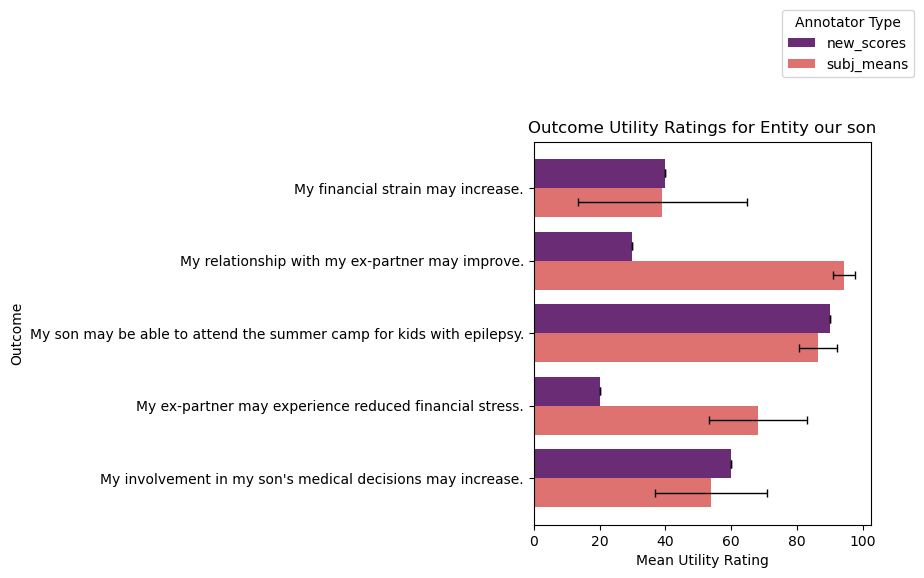

In [186]:
plot_utils(new_util_data, 1)

#### Step 4. Cause / Intend / Know Links

In [ ]:
#Step 4. causal / intentional / knowledge links -- run on currently generated event/outcome list
# output_links = annotate_scenario.process_causal_links(this_scenario_Ziv, events_Ziv, events_I, this_act_Ziv,g)    

In [329]:
#Step 4. Run on the human annotated events list 
output_links = annotate_scenario.process_causal_links(this_scenario_Ziv, annotated_outcomes_Ziv, annotated_outcomes_I, this_act_Ziv,g)   


Processing event: I help the person who crashed on the bike.
{'cause': 'yes', 'intend': 'yes', 'know': 'yes'}
CKI links for I
C+I+K+

Processing event: I arrive late to my first day of work.
{'cause': 'yes', 'intend': 'yes', 'know': 'yes'}
CKI links for I
C+I+K+

Processing event: The person who crashed may receive necessary immediate assistance.
{'cause': 'yes', 'intend': 'yes', 'know': 'no'}
CKI links for I
C+I+K-

Processing event: My boss may be upset due to my tardiness.
{'cause': 'yes', 'intend': 'no', 'know': 'yes'}
CKI links for I
C+I-K+

Processing event: I may feel good about helping someone in need despite the potential consequences at work.
{'cause': 'yes', 'intend': 'no', 'know': 'no'}
CKI links for I
C+I-K-


In [244]:
this_act_I

'I decide to ask her how she would prefer we proceed'

In [330]:
analyze_links(output_links)

/Users/anna/Dropbox/2023_AOI/MoralLearning/CodeSets/graph_extract/data/human_annotation//scenarios_2_choice_1_outcome_links.csv
The binary agreement between new annotator and human data on links is 0.73
The binary agreement between original annotator and human data on links is 0.60


In [137]:
hd_links = get_human_data_links()
hd_links['subj_mean'] = hd_links['subj_mean'].round().astype(int)
hd_links

/Users/anna/Dropbox/2023_AOI/MoralLearning/CodeSets/graph_extract/data/human_annotation//scenarios_2_choice_2_outcome_links.csv


,outcome_name,link_type,annot_links,p1,p10,p2,p3,p4,p5,p6,p7,p8,subj_mean,agreement_percentage,subj_se
0,I arrive on time for my first day of work.,Cause,0,1,0,0,1,1,1,1,0,0,1,0.444444,0.186339
1,I arrive on time for my first day of work.,Intend,1,1,0,0,0,1,1,0,0,1,0,0.444444,0.186339
2,I arrive on time for my first day of work.,Expect,1,0,0,0,1,1,1,0,1,1,1,0.555556,0.186339
3,I avoid potentially upsetting my boss by being...,Cause,1,1,1,0,0,1,1,0,1,1,1,0.666667,0.176777
4,I avoid potentially upsetting my boss by being...,Intend,1,0,1,0,0,1,1,1,1,1,1,0.666667,0.176777
5,I avoid potentially upsetting my boss by being...,Expect,1,0,0,0,1,0,1,0,0,1,0,0.333333,0.176777
6,The person who crashed may not receive immedia...,Cause,0,1,1,1,1,1,1,0,1,0,1,0.222222,0.155902
7,The person who crashed may not receive immedia...,Intend,0,0,1,1,1,1,1,0,0,1,1,0.333333,0.176777
8,The person who crashed may not receive immedia...,Expect,1,0,1,1,0,0,1,1,1,0,1,0.555556,0.186339
9,I may experience feelings of guilt or regret f...,Cause,0,1,1,0,0,1,1,0,1,0,1,0.444444,0.186339


In [ ]:
#optional -- write out the results 

this_output_filename = f"scenarios_{SCENARIO_ID}_choice_{ACT_ID}.json"
print('\n\nWriting to file: '+this_output_filename)
g_print = g.print_graph()
utils.write_jsonlines(SCENARIO_DIR+this_output_filename,g_print)
print('\n\n')


translate_to_vis.main(SCENARIO_DIR+this_output_filename)




Writing to file: scenarios_0_choice_1_test.json



